In [5]:
import numpy as np
from numpy import *
import bisect
import scipy as sp
from scipy.stats import gaussian_kde, ttest_ind
import numpy.matlib 
import math
from scipy import signal
from scipy import stats
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy as cart
import cartopy.crs as ccrs
from datetime import *
import datetime as datet
from dateutil.relativedelta import relativedelta, MO
import calendar
import matplotlib.animation as animation
from matplotlib import rc
from dask.distributed import Client, LocalCluster
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as mcolors
import os
import glob
import cartopy.feature as cfeature
from tqdm import tqdm

In [6]:
# Set up cluster
cluster = LocalCluster(n_workers=4, threads_per_worker=4)
client = Client(cluster)
client

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/distributed/node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42045 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42045/status,
Dashboard: http://127.0.0.1:42045/status,Workers: 4
Total threads: 16,Total memory: 235.37 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45603,Workers: 4
Dashboard: http://127.0.0.1:42045/status,Total threads: 16
Started: Just now,Total memory: 235.37 GiB
Comm: tcp://127.0.0.1:38745,Total threads: 4
Dashboard: http://127.0.0.1:38749/status,Memory: 58.84 GiB
Nanny: tcp://127.0.0.1:41073,


In [7]:
lhf_oa = xr.open_dataset('/work/bm1398/m301111/Observations/OA_Flux/lh_oaflux_1985-2018.nc')
lhf_era5 = xr.open_dataset('/work/bm1398/m301111/Reanalysis/ERA5/daily/ERA5__surface_latent_heat_flux__1979-2019.nc')

/tmp/ipykernel_233171/1022626157.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


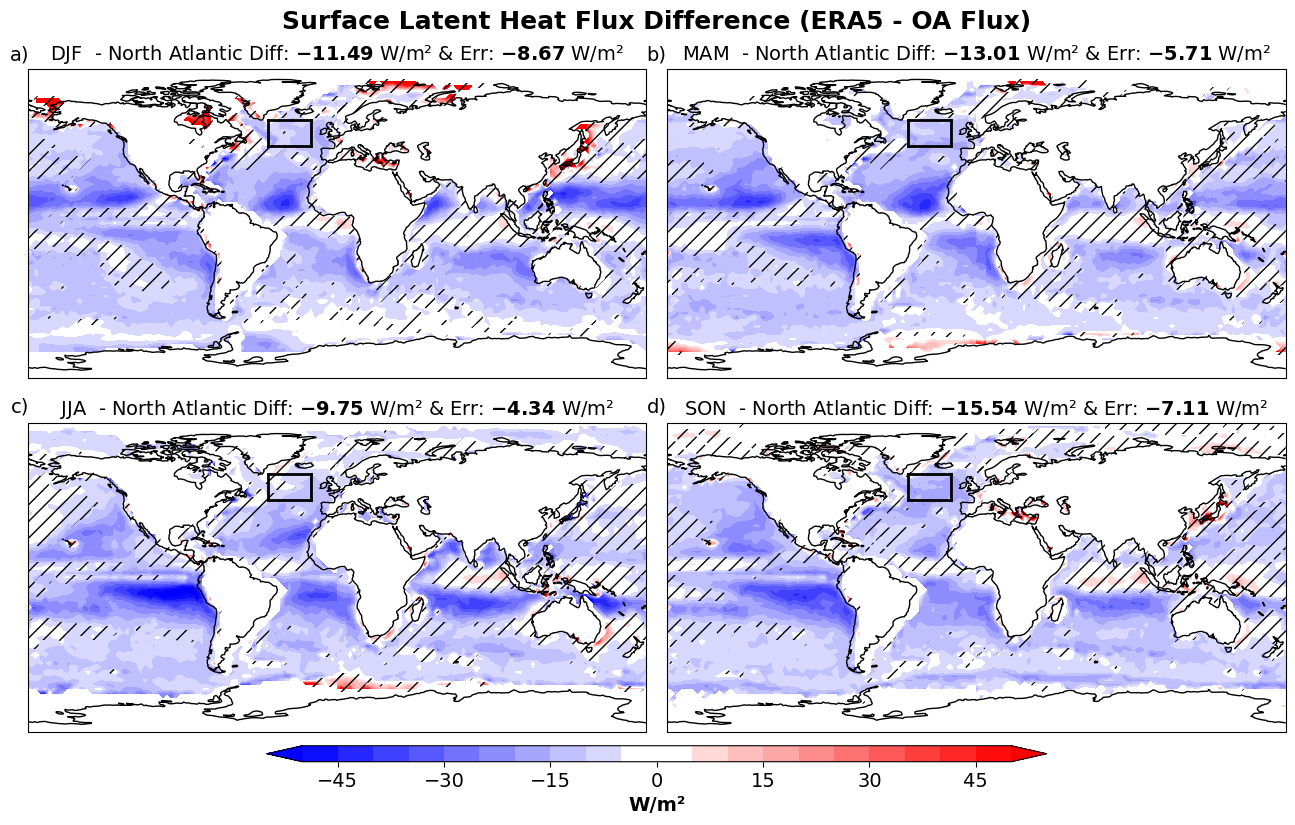

In [4]:
plt.rcParams['font.size'] = '14'

# Compute seasonal means
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11]}

lhf_diff_seasonal = {}
regional_means = {}
regional_errs = {}

weights = np.cos(np.deg2rad(lhf_era5.lat)) 

############

x1, y1 = [-40, -15], [45, 45]
x2, y2 = [-40, -15], [60, 60]
x3, y3 = [-40, -40], [45, 60]
x4, y4 = [-15, -15], [45, 60]

for season, months in seasons.items():
    era5_season = lhf_era5['var147'].sel(time=lhf_era5['time'].dt.month.isin(months)).groupby("time.year").mean(dim="time").mean(dim="year")*(-1)
    oa_season = lhf_oa['lhtfl'].sel(time=lhf_oa['time'].dt.month.isin(months)).groupby("time.year").mean(dim="time").mean(dim="year")*(-1)
    oa_season_err = lhf_oa['err'].sel(time=lhf_oa['time'].dt.month.isin(months)).groupby("time.year").mean(dim="time").mean(dim="year")*(-1)

    diff = era5_season - oa_season
    lhf_diff_seasonal[season] = diff

    # Compute regional average over 45-60°N, 15-40°W
    regional_mean = diff.sel(lat=slice(60.0, 45.0), lon=slice(320.0, 345.0)).weighted(weights).mean(dim=["lat", "lon"]).item()
    regional_err = oa_season_err.sel(lat=slice(60.0, 45.0), lon=slice(320.0, 345.0)).weighted(weights).mean(dim=["lat", "lon"]).item()

    regional_means[season] = regional_mean
    regional_errs[season] = regional_err

# Plot the differences
fig, axes = plt.subplots(2, 2, figsize=(13, 8), subplot_kw={'projection': ccrs.PlateCarree()}, rasterized=True)

levels = np.linspace(-50, 50, 21)  # Adjust based on data range
### Adjust Colormap
white = np.array([1., 1., 1., 1.])
bwr = plt.cm.get_cmap('bwr', 256)
bwr_white = bwr(np.linspace(0, 1, 256))
bwr_white[112:144, :] = white
bwr_white_cm= ListedColormap(bwr_white)

for ax, (season, diff) in zip(axes.flatten(), lhf_diff_seasonal.items()):
    lon = diff.coords["lon"]  
    lat = diff.coords["lat"]  
    im = ax.contourf(np.linspace(0,365,145), lat, np.c_[diff, diff[:,0]], levels=levels, cmap=bwr_white_cm, extend="both", transform=ccrs.PlateCarree())
    ax.contourf(np.linspace(0,365,145), lat, np.c_[(oa_season_err), (oa_season_err) [:,0]] < np.c_[diff, diff[:,0]], 1, hatches=['','//'], alpha=0)

    ax.coastlines()
    ax.set_title(f"{season}  - North Atlantic Diff: "  
             + r"$\mathbf{" + f"{regional_means[season]:.2f}" + "}$ W/m² & Err: "  
             + r"$\mathbf{" + f"{regional_errs[season]:.2f}" + "}$ W/m²", fontsize=14)
    ax.plot(x1, y1, x2, y2,x3,y3,x4,y4, color='black', linestyle='-', linewidth=2)


# Add a single colorbar at the bottom
cbar_ax = fig.add_axes([0.2, 0.02, 0.6, 0.02])  # Position: [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("W/m²", fontweight='bold')

plt.suptitle('Surface Latent Heat Flux Difference (ERA5 - OA Flux)', y=0.96, fontweight='bold', fontsize=18)
plt.tight_layout()

plt.figtext(0.01,0.915,"a)", ha="center", va="top")
plt.figtext(0.50,0.915,"b)", ha="center", va="top")
plt.figtext(0.01,0.475,"c)", ha="center", va="top")
plt.figtext(0.50,0.475,"d)", ha="center", va="top")

plt.savefig('figs/figs_revision/figS1_hatching.pdf', bbox_inches='tight')